# Trabajo Práctico N°2
## Problema 1: Clasificación de Razas de Perros con CNN desde cero

**Integrantes:** Sebastian Palacio, Juana Chies Doumecq

**Objetivo:** Construir, entrenar y optimizar una red neuronal convolucional **desde cero** (sin transfer learning) para clasificar imágenes de razas de perros, experimentando sistemáticamente con distintas decisiones de diseño arquitectónico y de entrenamiento.

**Dataset:** [70 Dog Breeds Image Dataset](https://www.kaggle.com/datasets/gpiosenka/70-dog-breedsimage-data-set) — subconjunto de 7 razas seleccionadas.

> ⚠️ **Restricción:** Queda prohibido el uso de modelos preentrenados o transfer learning. Todos los pesos deben inicializarse aleatoriamente y entrenarse sobre el dataset.


## 1. Configuración y reproducibilidad

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from PIL import Image
import os
import time
import copy
import random
from pathlib import Path
from tqdm import tqdm


### Semilla fija para reproducibilidad

Los algoritmos de Deep Learning usan números aleatorios en inicialización de pesos, data augmentation y orden de batches. Fijar todas las semillas garantiza que dos ejecuciones con el mismo código produzcan exactamente los mismos resultados.


In [106]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)


### Configuración del dispositivo

PyTorch puede ejecutarse en CPU, GPU NVIDIA (CUDA) o GPU Apple Silicon (MPS). El código detecta automáticamente el hardware disponible y usa el más rápido.


In [107]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("=" * 60)
print("CONFIGURACIÓN DEL ENTORNO")
print("=" * 60)
print(f"  PyTorch versión    : {torch.__version__}")
print(f"  Dispositivo        : {device}")
print(f"  CUDA disponible    : {torch.cuda.is_available()}")
print(f"  MPS disponible     : {torch.backends.mps.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU modelo         : {torch.cuda.get_device_name(0)}")
print(f"  Semilla fija       : {SEED}")
print("=" * 60)


CONFIGURACIÓN DEL ENTORNO
  PyTorch versión    : 2.12.0+cpu
  Dispositivo        : cpu
  CUDA disponible    : False
  MPS disponible     : False
  Semilla fija       : 42


## 2. Carga e inspección del dataset

### Dataset: 70 Dog Breeds Image Dataset (Kaggle)

El dataset ya viene **pre-dividido** por el autor en tres splits (`train / valid / test`), organizados en carpetas donde cada subcarpeta es una raza. Esto permite usar directamente `ImageFolder` de torchvision sin necesidad de hacer splits manuales.

```
Datasets/problema 1/
└── train/          valid/          test/
    ├── Beagle/         ├── Beagle/     ├── Beagle/
    ├── Boxer/          ├── Boxer/      ├── Boxer/
    └── ...             └── ...         └── ...
```

### Reducción del problema

Siguiendo la recomendación del enunciado, trabajamos con **7 razas** seleccionadas por variedad morfológica:

| Raza | Característica distintiva |
|---|---|
| Beagle | Tricolor, orejas largas caídas |
| Boxer | Cara chata, musculoso |
| Bulldog | Muy arrugado, compacto |
| Chihuahua | Tamaño muy pequeño, orejas grandes |
| German Shepherd | Grande, bicolor, orejas erectas |
| Golden Retriever | Pelaje dorado largo |
| Siberian Husky | Ojos claros, máscara facial |


In [108]:
# ── Rutas del dataset ─────────────────────────────────────────
# El dataset se descarga con kagglehub y se copia manualmente a esta ruta,
# o se referencia directamente desde la caché de kagglehub.
# Ajustar DATASET_ROOT si la ruta local es distinta.
DATASET_ROOT = Path("./Datasets/problema 1")

# Si el dataset no está en la ruta esperada, intentamos descargarlo con kagglehub
if not (DATASET_ROOT / "train").exists():
    print("  Dataset no encontrado en ruta local. Intentando con kagglehub...")
    try:
        import kagglehub
        ruta_cache = kagglehub.dataset_download("gpiosenka/70-dog-breedsimage-data-set")
        ruta_cache = Path(ruta_cache)
        print(f"  Descargado en: {ruta_cache}")
        # Buscar subcarpeta con train/
        for candidato in [ruta_cache] + list(ruta_cache.rglob("train"))[:3]:
            c = candidato if candidato.is_dir() and (candidato / "train").exists() else candidato.parent
            if (c / "train").exists():
                DATASET_ROOT = c
                break
        print(f"  Usando raíz: {DATASET_ROOT}")
    except Exception as e:
        print(f"  Error: {e}")
        print("  Por favor descargá el dataset manualmente y colocalo en ./Datasets/problema 1/")

RUTA_TRAIN = DATASET_ROOT / "train"
RUTA_VAL   = DATASET_ROOT / "valid"
RUTA_TEST  = DATASET_ROOT / "test"

print(f"  Train : {RUTA_TRAIN}  — existe: {RUTA_TRAIN.exists()}")
print(f"  Val   : {RUTA_VAL}  — existe: {RUTA_VAL.exists()}")
print(f"  Test  : {RUTA_TEST}  — existe: {RUTA_TEST.exists()}")


  Train : Datasets\problema 1\train  — existe: True
  Val   : Datasets\problema 1\valid  — existe: True
  Test  : Datasets\problema 1\test  — existe: True


In [109]:
# ── Selección de razas ────────────────────────────────────────
# Nombres EXACTOS tal como aparecen en las carpetas del dataset.
# (Verificado del error de FileNotFoundError del ImageFolder)
RAZAS_FINAL = [
    'Beagle',
    'Boxer',
    'Chihuahua',
    'French Bulldog',     # el dataset no tiene "Bulldog" solo
    'German Sheperd',     # el dataset escribe "Sheperd" (sin segunda d)
    'Golden Retriever',
    'Husky',              # el dataset usa "Husky", no "Siberian Husky"
]

# Verificar que existan en disco — si alguna no existe, avisamos
clases_en_disco = sorted([p.name for p in RUTA_TRAIN.iterdir() if p.is_dir()])
faltantes = [r for r in RAZAS_FINAL if r not in clases_en_disco]
if faltantes:
    print(f"  ADVERTENCIA: estas razas no se encontraron en disco: {faltantes}")
    print(f"  Clases disponibles: {clases_en_disco}")
    # Ajuste automático: quitar las que no existen
    RAZAS_FINAL = [r for r in RAZAS_FINAL if r in clases_en_disco]

N_CLASES = len(RAZAS_FINAL)
print(f"  Razas seleccionadas ({N_CLASES}): {RAZAS_FINAL}")

# Función de filtro para ImageFolder
def solo_razas(ruta):
    return Path(ruta).parent.name in RAZAS_FINAL


  ADVERTENCIA: estas razas no se encontraron en disco: ['Husky']
  Clases disponibles: ['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberia

In [110]:
# ── Conteo de imágenes por clase y split ─────────────────────
ext_img = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def contar_por_clase(ruta_split, razas):
    return {r: sum(1 for f in (ruta_split / r).glob('*')
                   if f.suffix.lower() in ext_img)
            for r in razas if (ruta_split / r).exists()}

cnt_train = contar_por_clase(RUTA_TRAIN, RAZAS_FINAL)
cnt_val   = contar_por_clase(RUTA_VAL,   RAZAS_FINAL)
cnt_test  = contar_por_clase(RUTA_TEST,  RAZAS_FINAL)

total_tr = sum(cnt_train.values())
total_v  = sum(cnt_val.values())
total_te = sum(cnt_test.values())

print(f"  {'Raza':<22} {'Train':>6} {'Val':>5} {'Test':>5}")
print(f"  {'─'*42}")
for r in RAZAS_FINAL:
    print(f"  {r:<22} {cnt_train.get(r,0):>6} {cnt_val.get(r,0):>5} {cnt_test.get(r,0):>5}")
print(f"  {'─'*42}")
print(f"  {'TOTAL':<22} {total_tr:>6} {total_v:>5} {total_te:>5}")
print(f"\n  Total combinado: {total_tr + total_v + total_te:,} imágenes")

# Balance (solo si hay datos)
if cnt_train:
    vals  = list(cnt_train.values())
    ratio = max(vals) / min(vals)
    print(f"  Ratio max/min (train): {ratio:.2f}x → ", end="")
    print("BALANCEADO" if ratio < 2 else "DESBALANCEADO — considerar class weights")
else:
    print("  Sin datos — verificar que RAZAS_FINAL coincida con carpetas en disco.")


  Raza                    Train   Val  Test
  ──────────────────────────────────────────
  Beagle                    123    10    10
  Boxer                     134    10    10
  Chihuahua                 108    10    10
  French Bulldog             93    10    10
  German Sheperd            109    10    10
  Golden Retriever          127    10    10
  ──────────────────────────────────────────
  TOTAL                     694    60    60

  Total combinado: 814 imágenes
  Ratio max/min (train): 1.44x → BALANCEADO


## 3. Análisis exploratorio de datos (EDA)

Antes de entrenar cualquier modelo, es fundamental entender el dataset: ¿cómo se ven las imágenes? ¿Qué resoluciones tienen? ¿Están balanceadas las clases?


### 3.1 Muestras visuales por raza

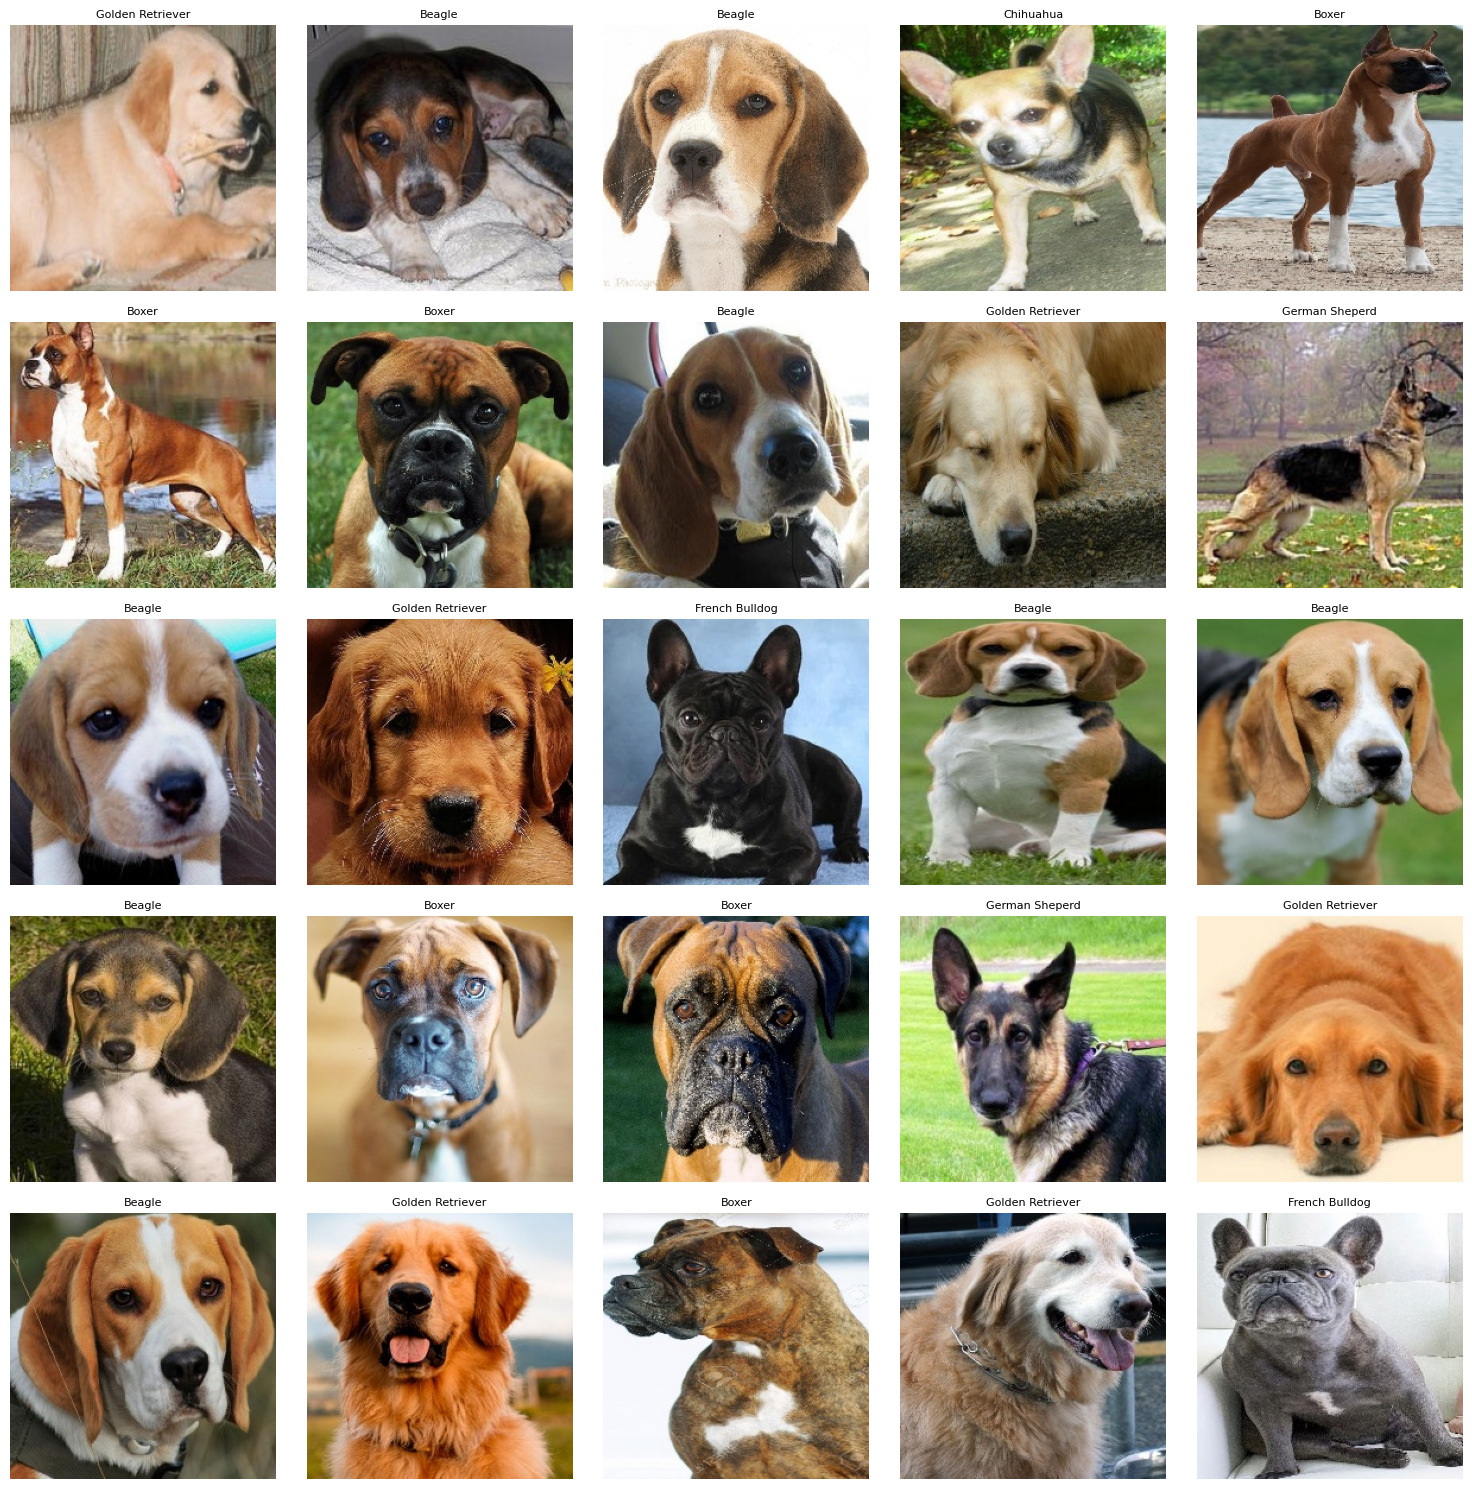

In [111]:
# Armar listas de rutas y etiquetas para todas las razas del train
X_train_paths = []
y_train_labels = []

for raza in RAZAS_FINAL:
    for f in (RUTA_TRAIN / raza).glob('*.*'):
        if f.suffix.lower() in ext_img:
            X_train_paths.append(f)
            y_train_labels.append(raza)

# Muestra aleatoria de 25 imágenes
indices = random.sample(range(len(X_train_paths)), 25)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for ax, idx in zip(axes.ravel(), indices):
    img = Image.open(X_train_paths[idx])
    ax.imshow(img)
    ax.set_title(y_train_labels[idx], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3.2 Distribución de clases por split

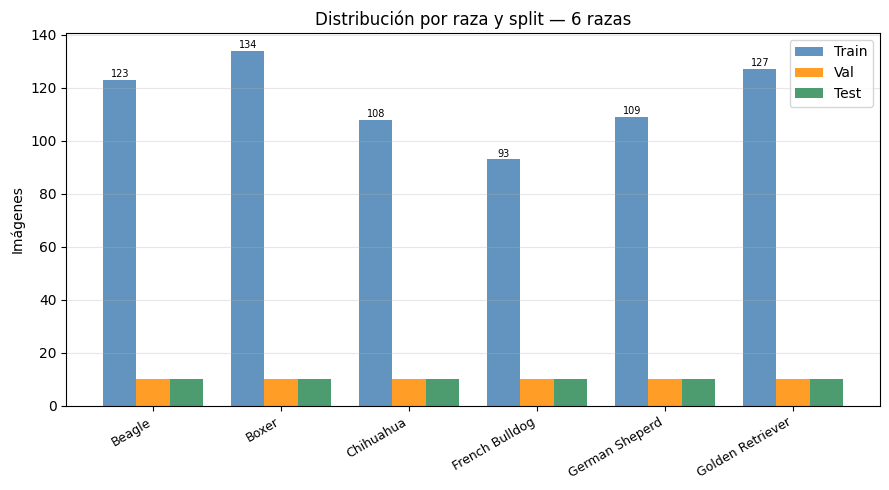

In [112]:
x     = np.arange(N_CLASES)
width = 0.26
fig, ax = plt.subplots(figsize=(max(8, N_CLASES * 1.5), 5))

b1 = ax.bar(x - width, [cnt_train.get(r, 0) for r in RAZAS_FINAL], width,
            label='Train', color='steelblue', alpha=0.85)
ax.bar(x,         [cnt_val.get(r, 0)   for r in RAZAS_FINAL], width,
       label='Val', color='darkorange', alpha=0.85)
ax.bar(x + width, [cnt_test.get(r, 0)  for r in RAZAS_FINAL], width,
       label='Test', color='seagreen', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(RAZAS_FINAL, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Imágenes')
ax.set_title(f'Distribución por raza y split — {N_CLASES} razas')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
            ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


### 3.3 Distribución de resoluciones originales

  Resoluciones originales (muestra de 90 imágenes):
    Ancho — min=224  max=224  media=224 px
    Alto  — min=224   max=224   media=224 px
    → Tamaños variables: necesitamos resize uniforme antes de entrenar.


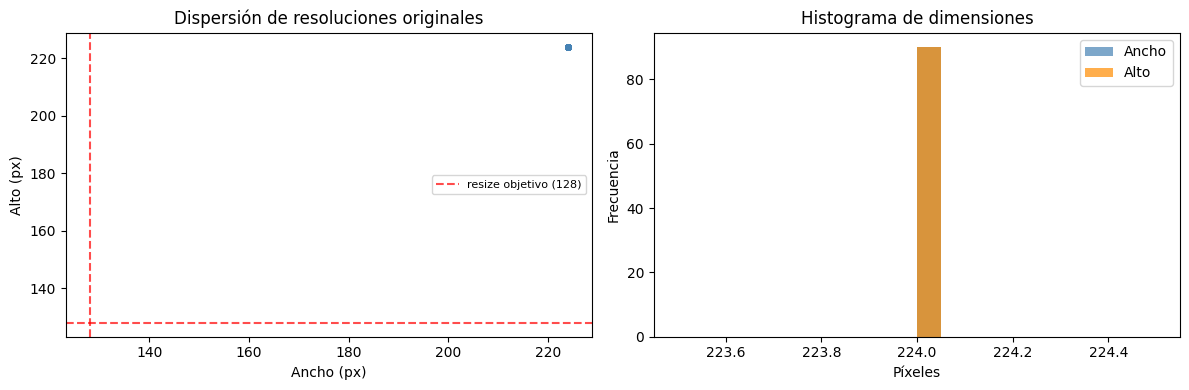

In [113]:
# Muestrear hasta 15 imágenes por raza para analizar resoluciones
anchos, altos, razas_tag = [], [], []
for raza in RAZAS_FINAL:
    archivos = list((RUTA_TRAIN / raza).glob('*.*'))[:15]
    for f in archivos:
        if f.suffix.lower() in ext_img:
            try:
                with Image.open(f) as im:
                    anchos.append(im.width)
                    altos.append(im.height)
                    razas_tag.append(raza)
            except Exception:
                pass

print(f"  Resoluciones originales (muestra de {len(anchos)} imágenes):")
print(f"    Ancho — min={min(anchos)}  max={max(anchos)}  media={np.mean(anchos):.0f} px")
print(f"    Alto  — min={min(altos)}   max={max(altos)}   media={np.mean(altos):.0f} px")
print(f"    → Tamaños variables: necesitamos resize uniforme antes de entrenar.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(anchos, altos, alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Ancho (px)'); axes[0].set_ylabel('Alto (px)')
axes[0].set_title('Dispersión de resoluciones originales')
axes[0].axvline(128, color='red', linestyle='--', alpha=0.7, label='resize objetivo (128)')
axes[0].axhline(128, color='red', linestyle='--', alpha=0.7)
axes[0].legend(fontsize=8)

axes[1].hist(anchos, bins=20, color='steelblue', alpha=0.7, label='Ancho')
axes[1].hist(altos,  bins=20, color='darkorange', alpha=0.7, label='Alto')
axes[1].set_xlabel('Píxeles'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma de dimensiones')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Preparación de datos

### Transforms y Data Augmentation

Se usan dos pipelines distintas:
- **Train**: Resize + augmentation (flips, rotación, color jitter) + ToTensor + Normalize
- **Val/Test**: solo Resize + ToTensor + Normalize (sin augmentation — evaluamos en condiciones reales)

La normalización usa los estadísticos de **ImageNet** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`). Aunque entrenamos desde cero, es práctica estándar usar estos valores como punto de partida porque están bien calibrados para imágenes naturales RGB.

**Tamaño de imagen:** 128×128. Suficiente para capturar rasgos morfológicos de razas (forma de cabeza, orejas, pelaje) y considerablemente más rápido de entrenar que 224×224.


In [114]:
IMG_SIZE   = 128
BATCH_SIZE = 32

# ── Transforms ───────────────────────────────────────────────
# TRAIN: augmentation para reducir overfitting.
# RandomHorizontalFlip: un perro visto de derecha ≡ visto de izquierda.
# RandomRotation: pequeñas rotaciones simulan ángulos de cámara distintos.
# ColorJitter: variaciones de iluminación, contraste y saturación.
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    # Normalización ImageNet: estandariza cada canal a media≈0, std≈1.
    # Estabiliza el entrenamiento aunque los pesos partan desde cero.
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# VAL/TEST: sin augmentation — evaluación en condiciones reales.
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [115]:
# ── ImageFolder correcto — subconjunto de razas ──────────────
# El problema con is_valid_file + allow_empty es que ImageFolder
# registra las 70 carpetas como clases (índices 0-69), pero solo
# carga archivos de las 7 razas. Los labels siguen siendo los
# índices originales (ej. Husky=36), pero el modelo tiene 7 salidas
# → IndexError: Target 36 is out of bounds.
#
# Solución: cargar el ImageFolder completo y filtrar + remap de labels.

dataset_train_full = datasets.ImageFolder(root=str(RUTA_TRAIN), transform=train_transforms)
dataset_val_full   = datasets.ImageFolder(root=str(RUTA_VAL),   transform=val_test_transforms)
dataset_test_full  = datasets.ImageFolder(root=str(RUTA_TEST),  transform=val_test_transforms)

# Índices originales de las razas seleccionadas (según orden alfabético del ImageFolder)
clases_full = dataset_train_full.classes          # lista de 70 razas
idx_razas   = [clases_full.index(r) for r in RAZAS_FINAL if r in clases_full]
CLASES_MODELO = [clases_full[i] for i in idx_razas]
remap         = {viejo: nuevo for nuevo, viejo in enumerate(idx_razas)}
IDX_TO_CLASS  = {nuevo: nombre for nuevo, nombre in enumerate(CLASES_MODELO)}

def hacer_subset(dataset_full):
    """
    Filtra muestras de las razas seleccionadas y reasigna labels
    a 0..N_CLASES-1. Devuelve un nuevo ImageFolder-like con solo
    esas muestras y labels correctos.
    """
    ds = copy.deepcopy(dataset_full)
    ds.samples  = [(p, remap[l]) for p, l in dataset_full.samples if l in remap]
    ds.targets  = [l for _, l in ds.samples]
    ds.classes  = CLASES_MODELO
    ds.class_to_idx = {c: i for i, c in enumerate(CLASES_MODELO)}
    return ds

dataset_train = hacer_subset(dataset_train_full)
dataset_val   = hacer_subset(dataset_val_full)
dataset_test  = hacer_subset(dataset_test_full)

print(f"  Clases ({len(CLASES_MODELO)}): {CLASES_MODELO}")
print(f"  class_to_idx : {dataset_train.class_to_idx}")
print(f"  Tamaños — Train: {len(dataset_train):,}  Val: {len(dataset_val):,}  Test: {len(dataset_test):,}")


  Clases (6): ['Beagle', 'Boxer', 'Chihuahua', 'French Bulldog', 'German Sheperd', 'Golden Retriever']
  class_to_idx : {'Beagle': 0, 'Boxer': 1, 'Chihuahua': 2, 'French Bulldog': 3, 'German Sheperd': 4, 'Golden Retriever': 5}
  Tamaños — Train: 694  Val: 60  Test: 60


In [116]:
# Celda reservada para experimentos alternativos.


In [117]:
# ── DataLoaders ───────────────────────────────────────────────
# shuffle=True en train: cada epoch el orden de batches es distinto.
# Evita que el modelo aprenda atajos dependientes del orden de presentación.
# num_workers=2: carga de datos en paralelo mientras la GPU entrena.
# pin_memory=True: pre-carga en memoria fija → transferencia GPU más rápida.
train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"  Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")


  Batches — Train: 22  Val: 2  Test: 2


c:\Users\juana\OneDrive\Escritorio\TUIA\Aprendizaje automatico II\venvAA2\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


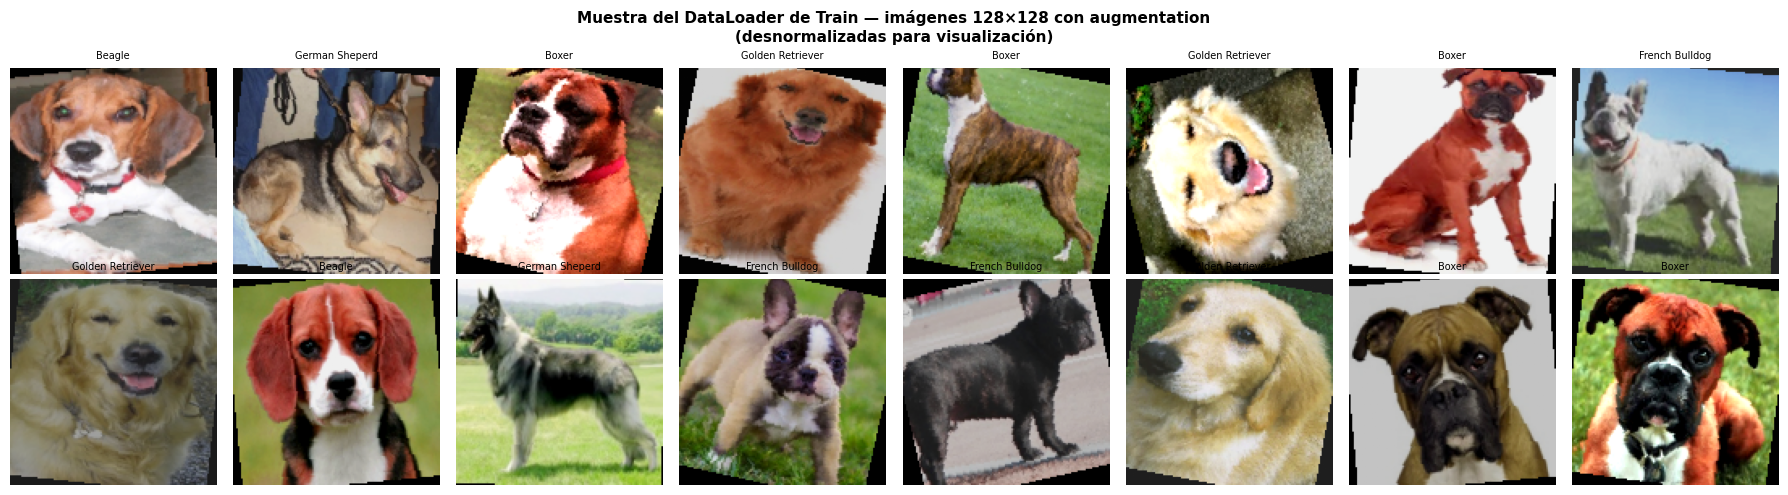

  Tensor shape de un batch: [32, 3, 128, 128]  (N×C×H×W)
  Rango tras Normalize: [-2.12, 2.64]


In [118]:
# ── Visualizar muestras del DataLoader (desnormalizadas) ──────
def desnormalizar(tensor_img):
    """Invierte la normalización ImageNet para visualizar correctamente."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor_img * std + mean, 0, 1)

muestra_imgs, muestra_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle(f'Muestra del DataLoader de Train — imágenes {IMG_SIZE}×{IMG_SIZE} con augmentation\n'
             f'(desnormalizadas para visualización)',
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < min(16, len(muestra_imgs)):
        img_vis = desnormalizar(muestra_imgs[i]).permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img_vis, 0, 1))
        ax.set_title(IDX_TO_CLASS[muestra_labels[i].item()], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"  Tensor shape de un batch: {list(muestra_imgs.shape)}  (N×C×H×W)")
print(f"  Rango tras Normalize: [{muestra_imgs.min():.2f}, {muestra_imgs.max():.2f}]")


## 5. Implementación CNN Base (E1)

### Arquitectura E1 — Línea base

Tres bloques **Conv → BN → ReLU → MaxPool** seguidos de una cabeza clasificadora densa. Esta es la arquitectura mínima que el enunciado describe como "E1 — Línea base".

**¿Por qué BatchNorm?**
Normaliza las activaciones de cada capa durante el entrenamiento (media≈0, std≈1 por batch). Beneficios: (1) permite LR más altos, (2) actúa como regularizador implícito, (3) reduce la sensibilidad a la inicialización de pesos.

**¿Por qué MaxPool?**
Reduce el tamaño espacial a la mitad en cada bloque, disminuyendo el costo computacional y añadiendo invarianza a pequeñas traslaciones de la imagen.


In [119]:
class CNNBase(nn.Module):
    """
    CNN Base (E1): 3 bloques Conv-BN-ReLU-MaxPool + cabeza clasificadora.
    Arquitectura mínima para establecer la línea base del experimento.
    """
    def __init__(self, num_classes=7):
        super().__init__()

        # ── Bloque 1 ─────────────────────────────────────────
        # Entrada: (B, 3, 128, 128)
        # Conv2d(3→32, 3×3): 32 filtros que detectan patrones simples
        #   (bordes, texturas) en los 3 canales RGB de entrada.
        # padding=1: mantiene las dimensiones espaciales (128 → 128 antes del pool).
        # Salida tras MaxPool: (B, 32, 64, 64)
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 128 → 64
        )

        # ── Bloque 2 ─────────────────────────────────────────
        # Entrada: (B, 32, 64, 64)
        # Duplicamos filtros: 32 → 64. La jerarquía de features crece:
        # combinaciones de patrones del bloque anterior.
        # Salida tras MaxPool: (B, 64, 32, 32)
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 64 → 32
        )

        # ── Bloque 3 ─────────────────────────────────────────
        # Entrada: (B, 64, 32, 32)
        # 64 → 128 filtros: features de mayor abstracción.
        # Salida tras MaxPool: (B, 128, 16, 16)
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 32 → 16
        )

        # ── Cabeza clasificadora ──────────────────────────────
        # AdaptiveAvgPool2d(1,1): colapsa el mapa espacial 16×16 a 1×1
        # (promedio global). Ventaja: la cabeza es independiente del IMG_SIZE.
        # Flatten: (B, 128, 1, 1) → (B, 128)
        # Dropout(0.5): regularización — en cada forward de train, apaga
        # aleatoriamente el 50% de las neuronas. Previene co-adaptación
        # y reduce overfitting.
        # Linear(128 → num_classes): produce logits, uno por clase.
        self.cabeza = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        x = self.cabeza(x)
        return x   # logits (sin Softmax — CrossEntropyLoss los aplica internamente)


# ── Instanciar e inspeccionar ─────────────────────────────────
model = CNNBase(num_classes=N_CLASES).to(device)

# Contar parámetros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("  ARQUITECTURA E1 — CNN Base")
print("=" * 60)
print(model)
print("=" * 60)
print(f"  Parámetros totales     : {total_params:,}")
print(f"  Parámetros entrenables : {trainable_params:,}")
print("=" * 60)

# Verificar con un forward pass de prueba
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
print(f"\n  Forward pass OK — input: {list(dummy.shape)} → output: {list(out.shape)}")


  ARQUITECTURA E1 — CNN Base
CNNBase(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cabeza): S

## 6. Entrenamiento y evaluación

### Función de entrenamiento reutilizable

Encapsulamos el loop de entrenamiento para poder reutilizarlo en todos los experimentos (E1–E4) sin duplicar código. Implementa:

- **Early stopping:** guarda los mejores pesos y detiene el entrenamiento si `val_loss` no mejora en `patience` epochs.
- **ReduceLROnPlateau:** reduce el learning rate cuando la pérdida de validación se estanca.
- **Checkpoints:** guarda el mejor modelo en disco para poder retomarlo si se interrumpe.


In [120]:
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss = LogSoftmax + NLLLoss en un solo paso.
# Recibe logits crudos (salida del modelo sin activación).
# NUNCA aplicar Softmax antes: duplicaría la operación y produciría resultados incorrectos.

def entrenar(model, loader_train, loader_val, optimizador, scheduler,
             n_epochs, patience, etiqueta, checkpoint_path=None):
    """
    Loop de entrenamiento con early stopping y ReduceLROnPlateau.
    Retorna (history, best_weights).
    history: dict con listas train_loss, val_loss, train_acc, val_acc por epoch.
    """
    best_val_loss    = float('inf')
    patience_counter = 0
    best_weights     = copy.deepcopy(model.state_dict())
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n[{etiqueta}] Entrenamiento — máx {n_epochs} epochs, patience={patience}")
    print("-" * 60)

    for epoch in range(n_epochs):
        t0 = time.time()

        # ── TRAIN ────────────────────────────────────────────
        # model.train(): activa Dropout y BatchNorm en modo entrenamiento.
        model.train()
        running_loss = 0.0
        correct = total = 0

        for imgs, labels in tqdm(loader_train,
                                  desc=f"  Epoch {epoch+1}/{n_epochs} [Train]",
                                  leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizador.zero_grad()          # limpiar gradientes anteriores
            outputs = model(imgs)            # forward: logits (B, num_clases)
            loss    = criterion(outputs, labels)
            loss.backward()                  # backpropagation
            optimizador.step()               # actualizar pesos

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── VALIDACIÓN ────────────────────────────────────────
        # model.eval(): desactiva Dropout y usa estadísticos acumulados de BN.
        # torch.no_grad(): no construye el grafo de autograd → ahorra memoria y tiempo.
        model.eval()
        val_loss_acc = val_correct = val_total = 0.0

        with torch.no_grad():
            for imgs, labels in loader_val:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs  = model(imgs)
                loss     = criterion(outputs, labels)
                val_loss_acc += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss_acc / val_total
        val_acc  = val_correct  / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        t_ep = time.time() - t0
        print(f"  Epoch {epoch+1:>3}/{n_epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f} | {t_ep:.1f}s")

        # ── Early stopping ────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_weights     = copy.deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save({'epoch': epoch, 'model_state_dict': best_weights,
                            'val_loss': best_val_loss}, checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping en epoch {epoch+1} (patience={patience})")
                break

        # ── ReduceLROnPlateau ─────────────────────────────────
        scheduler.step(val_loss)

    # Restaurar los mejores pesos antes de retornar
    model.load_state_dict(best_weights)
    print(f"\n  [{etiqueta}] Mejor val_loss: {best_val_loss:.4f}")
    return history, best_weights


def evaluar_en_test(model, loader):
    """Evalúa el modelo en test. Retorna (preds, labels_reales, accuracy)."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()
    return all_preds, all_labels, acc


### Entrenamiento del modelo E1 (línea base)

In [121]:
# Celda reservada.


In [122]:
# ── Reiniciar modelo para E1 ──────────────────────────────────
set_seed(SEED)
model_e1 = CNNBase(num_classes=N_CLASES).to(device)

# Adam: optimizador con momento adaptativo por parámetro.
# lr=1e-3: punto de partida estándar para CNNs desde cero.
# weight_decay=1e-4: regularización L2 — penaliza pesos grandes.
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=1e-3, weight_decay=1e-4)

# ReduceLROnPlateau: si val_loss no baja en 3 epochs, lr ← lr × 0.5
scheduler_e1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_e1, mode='min', patience=3, factor=0.5
)

history_e1, best_weights_e1 = entrenar(
    model_e1, train_loader, val_loader,
    optimizer_e1, scheduler_e1,
    n_epochs=30, patience=7,
    etiqueta="E1 — CNN Base",
    checkpoint_path="checkpoint_e1.pth"
)



[E1 — CNN Base] Entrenamiento — máx 30 epochs, patience=7
------------------------------------------------------------


  Epoch   1/30 | train_loss=1.7792 acc=0.241 | val_loss=1.6540 acc=0.383 | 34.9s


  Epoch   2/30 | train_loss=1.6190 acc=0.353 | val_loss=1.5984 acc=0.417 | 31.8s


  Epoch   3/30 | train_loss=1.5603 acc=0.379 | val_loss=1.5619 acc=0.400 | 30.5s


  Epoch   4/30 | train_loss=1.5630 acc=0.373 | val_loss=1.5148 acc=0.467 | 30.0s


...

  Epoch   8/30 | train_loss=1.4550 acc=0.421 | val_loss=1.5518 acc=0.417 | 43.8s


  Epoch   9/30 | train_loss=1.5090 acc=0.396 | val_loss=1.4954 acc=0.467 | 45.4s


  Epoch  10/30 | train_loss=1.4414 acc=0.444 | val_loss=1.5646 acc=0.417 | 47.4s


  Epoch  11/30 | train_loss=1.4938 acc=0.399 | val_loss=1.5631 acc=0.417 | 37.1s


KeyboardInterrupt: 

In [ ]:
# ── Evaluar E1 en test ────────────────────────────────────────
preds_e1, labels_e1, test_acc_e1 = evaluar_en_test(model_e1, test_loader)
print(f"  [E1] Test Accuracy: {test_acc_e1:.4f} ({test_acc_e1*100:.2f}%)")


### Curvas de aprendizaje E1

In [ ]:
def graficar_curvas(history, titulo, fname=None):
    """Grafica train/val loss y accuracy por epoch."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(titulo, fontsize=12, fontweight='bold')
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('CrossEntropy Loss')
    ax1.set_title('Pérdida por Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='darkorange')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy por Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

graficar_curvas(history_e1, 'E1 — CNN Base: curvas de aprendizaje', 'p1_curvas_e1.png')


### Matriz de confusión y reporte de clasificación — E1

In [ ]:
def graficar_confusion(preds, labels, clases, titulo, fname=None):
    """Matriz de confusión normalizada por fila (recall por clase)."""
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues',
              xticks_rotation=30)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n  Reporte de clasificación:")
    print(classification_report(labels, preds, target_names=clases))

graficar_confusion(preds_e1, labels_e1, CLASES_MODELO,
                   'E1 — Matriz de Confusión (Test)', 'p1_confusion_e1.png')


### Visualización de predicciones correctas e incorrectas — E1

In [ ]:
# DataLoader temporal con shuffle para obtener imágenes variadas
_vis_loader = DataLoader(dataset_test, batch_size=16, shuffle=True, num_workers=0)
vis_imgs, vis_labels = next(iter(_vis_loader))

model_e1.eval()
with torch.no_grad():
    vis_out   = model_e1(vis_imgs.to(device))
    _, vis_preds = torch.max(vis_out, 1)

n_mostrar = 12
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('E1 — Predicciones en Test\n(verde = correcto, rojo = incorrecto)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < n_mostrar:
        img_vis  = desnormalizar(vis_imgs[i]).permute(1, 2, 0).numpy()
        pred_idx = vis_preds[i].item()
        true_idx = vis_labels[i].item()
        color    = 'green' if pred_idx == true_idx else 'red'
        ax.imshow(np.clip(img_vis, 0, 1))
        ax.set_title(f'Pred: {IDX_TO_CLASS[pred_idx]}\nReal: {IDX_TO_CLASS[true_idx]}',
                     color=color, fontsize=8, fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 7. Experimentos

Comparamos 4 experimentos siguiendo la progresión lógica del enunciado. Cada experimento parte del anterior e incorpora una o más mejoras.

| Experimento | Qué se modifica |
|---|---|
| **E1 — Línea base** | 3 bloques Conv-BN-ReLU-MaxPool + cabeza densa |
| **E2 — Arquitectura más profunda** | +capas conv, variación de filtros (3×3 vs 5×5) y strides |
| **E3 — Bloques avanzados** | Bloques residuales (skip connections estilo ResNet) |
| **E4 — Regularización + Data Aug** | Dropout mejorado, BN en toda la red, pipeline de augmentation completa |


### E2 — Arquitectura más profunda

In [ ]:
class CNNE2(nn.Module):
    """
    E2: Arquitectura más profunda.
    4 bloques conv con filtros crecientes (32→64→128→256).
    Tercer bloque usa kernel 5×5 para capturar features de mayor escala.
    Stride=2 en lugar de MaxPool en el último bloque (convolución con stride
    aprende mejor qué información preservar vs. MaxPool que toma el máximo fijo).
    """
    def __init__(self, num_classes=7):
        super().__init__()

        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 128 → 64
        )
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 64 → 32
        )
        # Kernel 5×5: campo receptivo mayor → features de escala intermedia
        # (p.ej. forma de oreja completa, no solo bordes locales)
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 32 → 16
        )
        # Stride=2 en lugar de MaxPool: la convolución strideada aprende
        # qué preservar; MaxPool simplemente toma el máximo.
        self.bloque4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            # 16 → 8  (stride=2 equivale a MaxPool en reducción espacial)
        )
        self.cabeza = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.bloque1(x); x = self.bloque2(x)
        x = self.bloque3(x); x = self.bloque4(x)
        return self.cabeza(x)


set_seed(SEED)
model_e2 = CNNE2(num_classes=N_CLASES).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_e2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_e2, mode='min', patience=3, factor=0.5, verbose=True)

history_e2, best_weights_e2 = entrenar(
    model_e2, train_loader, val_loader,
    optimizer_e2, scheduler_e2,
    n_epochs=30, patience=7,
    etiqueta="E2 — Más profunda",
    checkpoint_path="checkpoint_e2.pth"
)
preds_e2, labels_e2, test_acc_e2 = evaluar_en_test(model_e2, test_loader)
print(f"  [E2] Test Accuracy: {test_acc_e2:.4f} ({test_acc_e2*100:.2f}%)")
graficar_curvas(history_e2, 'E2 — Arquitectura profunda: curvas de aprendizaje', 'p1_curvas_e2.png')


### E3 — Bloques residuales (skip connections)

In [ ]:
class BloqueResidual(nn.Module):
    """
    Bloque residual estilo ResNet.
    Aprende F(x) = H(x) - x, donde H(x) es la transformación deseada.
    La skip connection suma la entrada x a la salida: y = F(x) + x.

    Ventajas:
    - Permite gradientes fluir directamente hacia capas anteriores
      (evita vanishing gradient en redes profundas).
    - El bloque puede aprender la identidad fácilmente (F(x)≈0),
      facilitando el entrenamiento de redes muy profundas.
    - Si el canal de entrada ≠ canal de salida, se usa una convolución 1×1
      para ajustar las dimensiones antes de sumar (proyección).
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # Proyección: si canales o dimensiones cambian, adaptar la skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        residual = self.shortcut(x)   # rama skip
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.relu(x + residual)   # suma elemento a elemento
        return x


class CNNE3(nn.Module):
    """
    E3: Bloques residuales estilo ResNet.
    Stem conv + 3 stages de bloques residuales con reducción de stride.
    """
    def __init__(self, num_classes=7):
        super().__init__()
        # Stem: extracción inicial de features con conv grande
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        # Stage 1: 32 canales, stride=2 para reducción espacial
        self.stage1 = BloqueResidual(32,  64,  stride=2)   # 128→64
        self.stage2 = BloqueResidual(64,  128, stride=2)   # 64→32
        self.stage3 = BloqueResidual(128, 256, stride=2)   # 32→16

        self.cabeza = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x)
        return self.cabeza(x)


set_seed(SEED)
model_e3 = CNNE3(num_classes=N_CLASES).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_e3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_e3, mode='min', patience=3, factor=0.5, verbose=True)

history_e3, best_weights_e3 = entrenar(
    model_e3, train_loader, val_loader,
    optimizer_e3, scheduler_e3,
    n_epochs=30, patience=7,
    etiqueta="E3 — Bloques residuales",
    checkpoint_path="checkpoint_e3.pth"
)
preds_e3, labels_e3, test_acc_e3 = evaluar_en_test(model_e3, test_loader)
print(f"  [E3] Test Accuracy: {test_acc_e3:.4f} ({test_acc_e3*100:.2f}%)")
graficar_curvas(history_e3, 'E3 — Bloques residuales: curvas de aprendizaje', 'p1_curvas_e3.png')


### E4 — Regularización mejorada + Data Augmentation completa

In [ ]:
# E4 reutiliza la arquitectura de E3 pero con:
# 1. Pipeline de augmentation más agresiva
# 2. Label smoothing en la función de pérdida
# 3. Scheduler CosineAnnealingLR (más suave que ReduceLROnPlateau)

# ── Augmentation más agresiva para E4 ────────────────────────
train_transforms_e4 = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),  # resize ligeramente mayor
    transforms.RandomCrop(IMG_SIZE),                    # recorte aleatorio → más variedad
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),   # raro, pero fuerza robustez a color
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset_train_e4 = datasets.ImageFolder(
    root=str(RUTA_TRAIN), transform=train_transforms_e4,
    is_valid_file=solo_razas
)
train_loader_e4 = DataLoader(dataset_train_e4, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=True)

# ── Label Smoothing ───────────────────────────────────────────
# En vez de targets one-hot duras [0,0,1,0], usa [ε/K, ε/K, 1-ε+ε/K, ε/K].
# Evita que el modelo sea demasiado confiado → mejor calibración y generalización.
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)

set_seed(SEED)
model_e4 = CNNE3(num_classes=N_CLASES).to(device)  # misma arquitectura que E3
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3, weight_decay=1e-4)

# CosineAnnealingLR: decae el LR suavemente siguiendo una coseno de T_max epochs.
# Evita oscilaciones del LR y mejora la convergencia final.
scheduler_e4 = optim.lr_scheduler.CosineAnnealingLR(optimizer_e4, T_max=30, eta_min=1e-5)

# Usamos criterio con label smoothing solo para E4
_criterion_orig = criterion   # guardar original
criterion = criterion_smooth

history_e4, best_weights_e4 = entrenar(
    model_e4, train_loader_e4, val_loader,
    optimizer_e4, scheduler_e4,
    n_epochs=30, patience=7,
    etiqueta="E4 — Regularización + Aug completa",
    checkpoint_path="checkpoint_e4.pth"
)
criterion = _criterion_orig   # restaurar criterio original

preds_e4, labels_e4, test_acc_e4 = evaluar_en_test(model_e4, test_loader)
print(f"  [E4] Test Accuracy: {test_acc_e4:.4f} ({test_acc_e4*100:.2f}%)")
graficar_curvas(history_e4, 'E4 — Regularización + Aug: curvas de aprendizaje', 'p1_curvas_e4.png')


## 8. Resultados finales

In [ ]:
# ── Tabla comparativa ─────────────────────────────────────────
resultados = {
    'E1 — Línea base':           {'acc_train': history_e1['train_acc'][-1],
                                   'acc_val':   history_e1['val_acc'][-1],
                                   'acc_test':  test_acc_e1,
                                   'epochs':    len(history_e1['train_loss']),
                                   'params':    sum(p.numel() for p in model_e1.parameters()),
                                   'obs':       '3 bloques Conv-BN-ReLU-MaxPool'},
    'E2 — Más profunda':         {'acc_train': history_e2['train_acc'][-1],
                                   'acc_val':   history_e2['val_acc'][-1],
                                   'acc_test':  test_acc_e2,
                                   'epochs':    len(history_e2['train_loss']),
                                   'params':    sum(p.numel() for p in model_e2.parameters()),
                                   'obs':       '4 bloques, kernel 5×5, stride conv'},
    'E3 — Bloques residuales':   {'acc_train': history_e3['train_acc'][-1],
                                   'acc_val':   history_e3['val_acc'][-1],
                                   'acc_test':  test_acc_e3,
                                   'epochs':    len(history_e3['train_loss']),
                                   'params':    sum(p.numel() for p in model_e3.parameters()),
                                   'obs':       'Skip connections estilo ResNet'},
    'E4 — Reg + Aug':            {'acc_train': history_e4['train_acc'][-1],
                                   'acc_val':   history_e4['val_acc'][-1],
                                   'acc_test':  test_acc_e4,
                                   'epochs':    len(history_e4['train_loss']),
                                   'params':    sum(p.numel() for p in model_e4.parameters()),
                                   'obs':       'E3 + label smooth + cos LR + aug agresiva'},
}

print("=" * 100)
print(f"  {'Experimento':<28} {'Acc Train':>10} {'Acc Val':>8} {'Acc Test':>9} "
      f"{'# Params':>10} {'Epochs':>7}  Observaciones")
print("=" * 100)
for exp, r in resultados.items():
    print(f"  {exp:<28} {r['acc_train']:>10.3f} {r['acc_val']:>8.3f} {r['acc_test']:>9.3f} "
          f"{r['params']:>10,} {r['epochs']:>7}  {r['obs']}")
print("=" * 100)

mejor = max(resultados.items(), key=lambda x: x[1]['acc_test'])
print(f"\n  ★ Mejor experimento en Test: {mejor[0]} — Acc={mejor[1]['acc_test']:.4f}")


### Comparación de curvas de todos los experimentos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación E1–E4: val_loss y val_acc por epoch', fontsize=12, fontweight='bold')

colores = ['steelblue', 'darkorange', 'seagreen', 'crimson']
nombres = ['E1 — Base', 'E2 — Profunda', 'E3 — Residual', 'E4 — Reg+Aug']
historiales = [history_e1, history_e2, history_e3, history_e4]

for h, nombre, color in zip(historiales, nombres, colores):
    epochs = range(1, len(h['val_loss']) + 1)
    axes[0].plot(epochs, h['val_loss'], label=nombre, color=color)
    axes[1].plot(epochs, h['val_acc'],  label=nombre, color=color)

for ax, titulo, ylabel in zip(axes,
    ['Val Loss por Epoch', 'Val Accuracy por Epoch'],
    ['CrossEntropy Loss', 'Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(titulo); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### Matriz de confusión y reporte del mejor modelo

In [ ]:
# Usar el mejor modelo según Test Accuracy
mejor_nombre = mejor[0]
mejor_preds  = {'E1 — Línea base': preds_e1, 'E2 — Más profunda': preds_e2,
                'E3 — Bloques residuales': preds_e3, 'E4 — Reg + Aug': preds_e4}[mejor_nombre]
mejor_labels = labels_e1  # todos tienen los mismos labels de test

graficar_confusion(mejor_preds, mejor_labels, CLASES_MODELO,
                   f'Mejor modelo ({mejor_nombre}) — Matriz de Confusión (Test)',
                   'p1_confusion_mejor.png')


In [ ]:
# Guardar mejor modelo completo
mejor_model = {'E1 — Línea base': model_e1, 'E2 — Más profunda': model_e2,
               'E3 — Bloques residuales': model_e3, 'E4 — Reg + Aug': model_e4}[mejor_nombre]

torch.save({
    'model_state_dict': mejor_model.state_dict(),
    'clases': CLASES_MODELO,
    'experimento': mejor_nombre,
    'test_accuracy': mejor[1]['acc_test'],
}, 'p1_mejor_modelo.pth')

print(f"  Modelo guardado en: p1_mejor_modelo.pth")
print(f"  Experimento: {mejor_nombre}")
print(f"  Test Accuracy: {mejor[1]['acc_test']:.4f} ({mejor[1]['acc_test']*100:.2f}%)")
